In [1]:
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    RocCurveDisplay, 
    precision_score, 
    classification_report
)
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN


In [2]:

path = "../Data/telco_customer_churn.csv"
df = pd.read_csv(path)

In [3]:
def encoding_func(df: pd.DataFrame) -> np.ndarray:
    """Encode The columns and shii.

    Args:
        df (pd.DataFrame): A raw pandas dataframe that has not been preprocessed in any way

    Returns:
        np.ndarray: A numpy array with labels for columns and all columns encoded and imputed. 
    """
    df = df.drop(columns=['customerID'], errors='ignore')
    from sklearn.preprocessing import OneHotEncoder
    yes_no_cols = dict()
    for col in df.columns:
        if df[col].nunique() <= 2:
            yes_no_cols[col] = list(df[col].unique())
    del yes_no_cols['gender']; del yes_no_cols['SeniorCitizen'] # Not Yes/No Columns. 
    for col in yes_no_cols.keys():
        df[col] = df[col].map({'Yes': 1, 'No': 0})

    # Manual Mappings. 
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
    df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
    df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': -1})

    yni = []
    for col in df.columns:
        if col in ['Contract', 'MultipleLines', 'InternetService']: continue # Skip these. 
        if df[col].nunique() == 3:
            yni.append(col)
    for col in yni:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': -1})

    ohe = OneHotEncoder(sparse_output=False)
    enc = ohe.fit_transform(df[['InternetService', 'PaymentMethod']]) # Nominal Categorical data. 
    temp = pd.DataFrame(enc, columns=ohe.get_feature_names_out())
    df = pd.concat([df.drop(columns=['InternetService', 'PaymentMethod']), temp], axis=1)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Has NaN values. 
    imp = SimpleImputer(strategy='mean')
    imp_mean = imp.fit_transform(df[['TotalCharges']])
    temp = pd.DataFrame(imp_mean, columns=imp.get_feature_names_out())
    df = pd.concat([df.drop(columns=['TotalCharges']), temp], axis=1)
    arr = np.asarray(df)
    return arr



prep = FunctionTransformer(encoding_func) # Integrate to scikit learn API. 

X = df.drop('Churn', axis=1)
X = prep.fit_transform(X)
y = df['Churn']
scores = cross_val_score(GradientBoostingClassifier(), X, y, cv=StratifiedKFold(5))
scores.mean()


np.float64(0.804061451545261)

c:\Users\USER\.vscode\python1\ML Projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


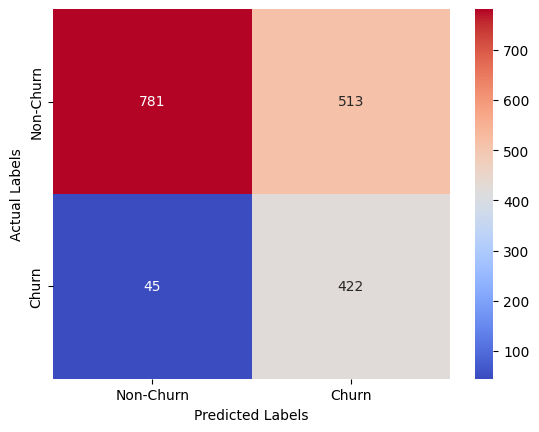

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
model = LogisticRegression(max_iter=3000, class_weight={'No': 1, 'Yes': 5})
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()
